# Q2d — Q1 vs Q2 comparison

**Not a training run.** Aggregates the JSON outputs of q1c/q1d (paste in below) and q2b/q2c into
the headline comparison table and figures the report needs.


In [1]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nlp_project import set_seed
from nlp_project.data import load_20ng
from nlp_project.eval import plot_confusion

set_seed()
FIG_DIR = Path('../figures'); FIG_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path('../models') / 'q2_results'
_, _, _, _, label_names = load_20ng(remove=True)


In [2]:
# Q1 final numbers pulled from the executed q1b/q1c/q1d notebooks.
q1_results = [
    {'name': 'Q1b word2vec mean-pool',     'accuracy': 0.6321, 'macro_f1': 0.6098},
    {'name': 'Q1c TF-IDF',                  'accuracy': 0.6964, 'macro_f1': 0.6895},
    {'name': 'Q1d word2vec mean+max-pool', 'accuracy': 0.6202, 'macro_f1': 0.6004},
]
q2b = json.loads((RESULTS_DIR / 'q2b_baseline.json').read_text())
q2c_rows = json.loads((RESULTS_DIR / 'q2c_sweep.json').read_text())
q2c_best = max(q2c_rows, key=lambda r: r['macro_f1'])
print('Q2 baseline:', q2b['name'], q2b['macro_f1'])
print('Q2 best    :', q2c_best['name'], q2c_best['macro_f1'])


Q2 baseline: q2b-bert-base-uncased-baseline 0.6888437180185493
Q2 best    : q2c-lr-5e-05 0.7038721772983243


In [3]:
table = pd.DataFrame(
    q1_results + [
        {'name': 'Q2b BERT baseline', 'accuracy': q2b['accuracy'], 'macro_f1': q2b['macro_f1']},
        {'name': f"Q2c best ({q2c_best['name']})", 'accuracy': q2c_best['accuracy'],
         'macro_f1': q2c_best['macro_f1']},
    ]
)
display(table)
table.to_csv(RESULTS_DIR / 'q1_vs_q2_table.csv', index=False)


,name,accuracy,macro_f1
0,Q1b word2vec mean-pool,0.632100,0.609800
1,Q1c TF-IDF,0.696400,0.689500
2,Q1d word2vec mean+max-pool,0.620200,0.600400
3,Q2b BERT baseline,0.708046,0.688844
4,Q2c best (q2c-lr-5e-05),0.718667,0.703872


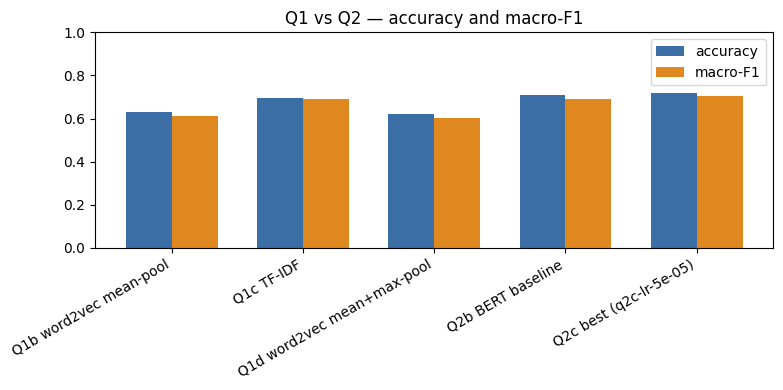

In [4]:
# Side-by-side bar chart.
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(table))
w = 0.35
ax.bar(x - w/2, table['accuracy'], w, label='accuracy', color='#3a6ea5')
ax.bar(x + w/2, table['macro_f1'], w, label='macro-F1', color='#e08820')
ax.set_xticks(x)
ax.set_xticklabels(table['name'], rotation=30, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Q1 vs Q2 — accuracy and macro-F1')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'q2d_comparison_bars.png', dpi=150)
plt.show()


In [5]:
# Q2 baseline confusion matrix — already saved in q2b; re-render here for completeness.
cm = np.array(q2b['confusion_matrix'])
plot_confusion(cm, label_names,
               save_path=FIG_DIR / 'q2d_q2b_cm.png',
               title='Q2 baseline — confusion matrix')


## Notes for the report

- BERT is expected to beat Q1's best by a clear margin on macro-F1; the per-class breakdown
  often shows the biggest gains on classes that share vocabulary (e.g. talk.* groups).
- Discuss compute trade-off: BERT-base has ~110M params vs Q1 MLP's small head — accuracy gain
  comes at a >100× training cost.
